# Import necessary libraries

In [147]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Load dataset

In [148]:
df = pd.read_csv("mrk0.csv")
df

,hospital_death,age,bmi,ethnicity,gender,height,hospital_admit_source,icu_admit_source,icu_stay_type,icu_type,...,aids,cirrhosis,diabetes_mellitus,hepatic_failure,immunosuppression,leukemia,lymphoma,solid_tumor_with_metastasis,apache_3j_bodysystem,apache_2_bodysystem
0,0,68.0,22.730000,2,1,180.3,4,1,0,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9,0
1,0,77.0,27.420000,2,0,160.0,4,1,0,5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8,6
2,0,25.0,31.950000,2,0,172.7,3,0,0,5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5,3
3,0,81.0,22.640000,2,0,165.1,8,2,0,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0
4,0,67.0,27.560000,2,1,190.5,2,0,0,5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50235,0,56.0,26.425600,2,1,182.9,3,0,0,6,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10,7
50236,0,82.0,31.887125,2,0,157.5,8,2,0,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0
50237,0,33.0,21.035756,2,1,177.8,3,0,0,5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5,3
50238,0,65.0,24.241173,2,1,172.7,15,3,0,6,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7,4


In [149]:
print("Shape:", df.shape)

Shape: (50240, 106)


In [153]:
df.head()

,hospital_death,age,bmi,ethnicity,gender,height,hospital_admit_source,icu_admit_source,icu_stay_type,icu_type,...,aids,cirrhosis,diabetes_mellitus,hepatic_failure,immunosuppression,leukemia,lymphoma,solid_tumor_with_metastasis,apache_3j_bodysystem,apache_2_bodysystem
0,0,68.0,22.73,2,1,180.3,4,1,0,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9,0
1,0,77.0,27.42,2,0,160.0,4,1,0,5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8,6
2,0,25.0,31.95,2,0,172.7,3,0,0,5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5,3
3,0,81.0,22.64,2,0,165.1,8,2,0,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0
4,0,67.0,27.56,2,1,190.5,2,0,0,5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7,4


# Data Types (Categorical vs Numeric)

In [103]:
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print("Categorical features:", categorical_cols)
print("Numeric features:", numeric_cols)

Categorical features: []
Numeric features: ['hospital_death', 'age', 'bmi', 'ethnicity', 'gender', 'height', 'hospital_admit_source', 'icu_admit_source', 'icu_stay_type', 'icu_type', 'pre_icu_los_days', 'weight', 'apache_2_diagnosis', 'apache_3j_diagnosis', 'apache_post_operative', 'arf_apache', 'bun_apache', 'creatinine_apache', 'gcs_eyes_apache', 'gcs_motor_apache', 'gcs_unable_apache', 'gcs_verbal_apache', 'glucose_apache', 'heart_rate_apache', 'hematocrit_apache', 'intubated_apache', 'map_apache', 'resprate_apache', 'sodium_apache', 'temp_apache', 'ventilated_apache', 'wbc_apache', 'd1_diasbp_max', 'd1_diasbp_min', 'd1_diasbp_noninvasive_max', 'd1_diasbp_noninvasive_min', 'd1_heartrate_max', 'd1_heartrate_min', 'd1_mbp_max', 'd1_mbp_min', 'd1_mbp_noninvasive_max', 'd1_mbp_noninvasive_min', 'd1_resprate_max', 'd1_resprate_min', 'd1_spo2_max', 'd1_spo2_min', 'd1_sysbp_max', 'd1_sysbp_min', 'd1_sysbp_noninvasive_max', 'd1_sysbp_noninvasive_min', 'd1_temp_max', 'd1_temp_min', 'h1_diasb

In [158]:
# Clinical parameters that are similar to our surgery parameters
CLINICAL_PARAMETERS_MAPPING = {
    # Demographics and basic info
    'age': 'Patient_Age',
    'bmi': 'BMI',
    'weight': 'Weight',
    'height': 'Height',
    
    # Clinical scores and diagnoses
    'apache_2_diagnosis': 'APACHE_2_Diagnosis',
    'apache_3j_diagnosis': 'APACHE_3J_Diagnosis', 
    'apache_4a_hospital_death_prob': 'APACHE_4a_Death_Probability',
    'apache_4a_icu_death_prob': 'APACHE_4a_ICU_Death_Probability',
    
    # Vital signs - using D1 (first day) measurements as baseline
    'd1_heartrate_max': 'Max_Heart_Rate',
    'd1_mbp_max': 'Max_Mean_BP',
    'd1_resprate_max': 'Max_Resp_Rate', 
    'd1_temp_max': 'Max_Temperature',
    'd1_spo2_min': 'Min_Oxygen_Saturation',
    
    # Lab values - using D1 measurements
    'd1_creatinine_max': 'Max_Creatinine',
    'd1_glucose_max': 'Max_Glucose',
    'd1_hemaglobin_max': 'Max_Hemoglobin',
    'd1_wbc_max': 'Max_WBC',
    'd1_bun_max': 'Max_BUN',
    
    # Comorbidities
    'diabetes_mellitus': 'Diabetes_Mellitus',
    'aids': 'AIDS',
    'cirrhosis': 'Cirrhosis',
    'hepatic_failure': 'Hepatic_Failure',
    
    # ICU status
    'pre_icu_los_days': 'Pre_ICU_LOS_Days',
    'arf_apache': 'Acute_Renal_Failure',
    'gcs_verbal_apache': 'GCS_Verbal',
    'gcs_motor_apache': 'GCS_Motor',
    'gcs_eyes_apache': 'GCS_Eyes'
}

print("🔍 MAPPING CLINICAL PARAMETERS")
print("="*60)

🔍 MAPPING CLINICAL PARAMETERS


In [159]:
# Find which mapped parameters exist in your dataset
available_mapped_params = []
for original_col, mapped_name in CLINICAL_PARAMETERS_MAPPING.items():
    if original_col in df.columns:
        available_mapped_params.append(original_col)
        print(f"✅ {original_col} -> {mapped_name}")

print(f"\n📊 Total mapped parameters: {len(available_mapped_params)}")

✅ age -> Patient_Age
✅ bmi -> BMI
✅ weight -> Weight
✅ height -> Height
✅ apache_2_diagnosis -> APACHE_2_Diagnosis
✅ apache_3j_diagnosis -> APACHE_3J_Diagnosis
✅ apache_4a_hospital_death_prob -> APACHE_4a_Death_Probability
✅ apache_4a_icu_death_prob -> APACHE_4a_ICU_Death_Probability
✅ d1_heartrate_max -> Max_Heart_Rate
✅ d1_mbp_max -> Max_Mean_BP
✅ d1_resprate_max -> Max_Resp_Rate
✅ d1_temp_max -> Max_Temperature
✅ d1_spo2_min -> Min_Oxygen_Saturation
✅ d1_creatinine_max -> Max_Creatinine
✅ d1_glucose_max -> Max_Glucose
✅ d1_hemaglobin_max -> Max_Hemoglobin
✅ d1_wbc_max -> Max_WBC
✅ d1_bun_max -> Max_BUN
✅ diabetes_mellitus -> Diabetes_Mellitus
✅ aids -> AIDS
✅ cirrhosis -> Cirrhosis
✅ hepatic_failure -> Hepatic_Failure
✅ pre_icu_los_days -> Pre_ICU_LOS_Days
✅ arf_apache -> Acute_Renal_Failure
✅ gcs_verbal_apache -> GCS_Verbal
✅ gcs_motor_apache -> GCS_Motor
✅ gcs_eyes_apache -> GCS_Eyes

📊 Total mapped parameters: 27


In [160]:
# Also include some additional important parameters that might be available
additional_params = [
    'hospital_admit_source', 'icu_admit_source', 'icu_type', 
    'intubated_apache', 'ventilated_apache', 'immunosuppression'
]

available_additional = [p for p in additional_params if p in df.columns]
print(f"📋 Additional available parameters: {len(available_additional)}")


📋 Additional available parameters: 6


In [161]:
# Combine all available parameters
all_available_params = available_mapped_params + available_additional

print(f"\n🎯 TOTAL FEATURES AVAILABLE: {len(all_available_params)}")


🎯 TOTAL FEATURES AVAILABLE: 33


In [162]:
print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData Types:\n", df.dtypes.value_counts())

Dataset Shape: (50240, 106)

Columns: ['hospital_death', 'age', 'bmi', 'ethnicity', 'gender', 'height', 'hospital_admit_source', 'icu_admit_source', 'icu_stay_type', 'icu_type', 'pre_icu_los_days', 'weight', 'apache_2_diagnosis', 'apache_3j_diagnosis', 'apache_post_operative', 'arf_apache', 'bun_apache', 'creatinine_apache', 'gcs_eyes_apache', 'gcs_motor_apache', 'gcs_unable_apache', 'gcs_verbal_apache', 'glucose_apache', 'heart_rate_apache', 'hematocrit_apache', 'intubated_apache', 'map_apache', 'resprate_apache', 'sodium_apache', 'temp_apache', 'ventilated_apache', 'wbc_apache', 'd1_diasbp_max', 'd1_diasbp_min', 'd1_diasbp_noninvasive_max', 'd1_diasbp_noninvasive_min', 'd1_heartrate_max', 'd1_heartrate_min', 'd1_mbp_max', 'd1_mbp_min', 'd1_mbp_noninvasive_max', 'd1_mbp_noninvasive_min', 'd1_resprate_max', 'd1_resprate_min', 'd1_spo2_max', 'd1_spo2_min', 'd1_sysbp_max', 'd1_sysbp_min', 'd1_sysbp_noninvasive_max', 'd1_sysbp_noninvasive_min', 'd1_temp_max', 'd1_temp_min', 'h1_diasbp_max

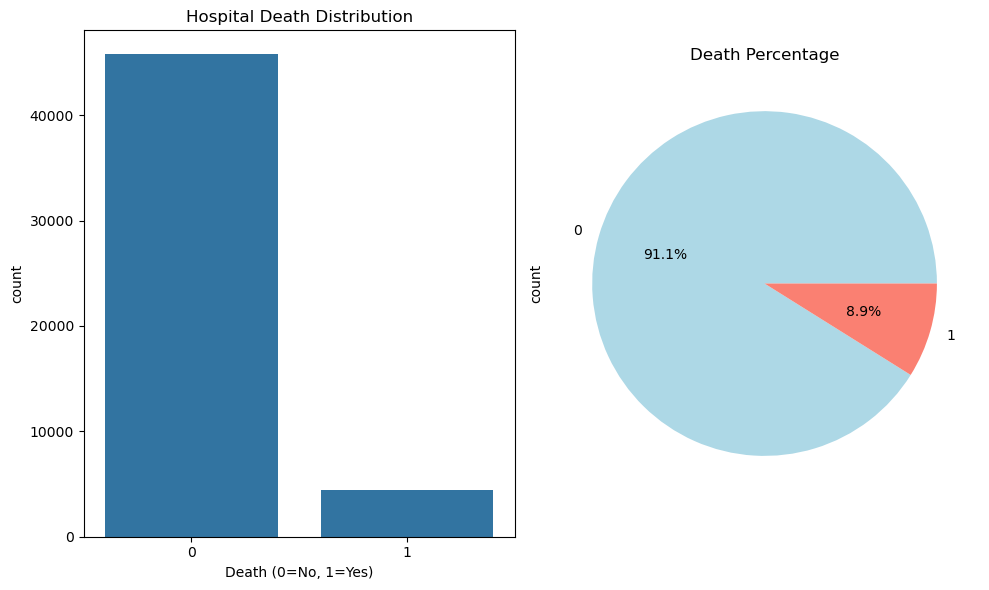

Target Distribution:
Survived (0): 45,770 patients (91.1%)
Died (1): 4,470 patients (8.9%)
⚠️  Highly imbalanced dataset - will use class weights in models


In [163]:
# # Target Variable Distribution

# %%
if 'hospital_death' in df.columns:
    plt.figure(figsize=(10, 6))
    
    plt.subplot(1, 2, 1)
    sns.countplot(x='hospital_death', data=df)
    plt.title('Hospital Death Distribution')
    plt.xlabel('Death (0=No, 1=Yes)')
    
    plt.subplot(1, 2, 2)
    df['hospital_death'].value_counts().plot.pie(autopct='%1.1f%%', colors=['lightblue', 'salmon'])
    plt.title('Death Percentage')
    
    plt.tight_layout()
    plt.show()

    target_stats = df['hospital_death'].value_counts()
    print("Target Distribution:")
    print(f"Survived (0): {target_stats[0]:,} patients ({target_stats[0]/len(df)*100:.1f}%)")
    print(f"Died (1): {target_stats[1]:,} patients ({target_stats[1]/len(df)*100:.1f}%)")
    
    # Check class balance
    if target_stats[1] / len(df) < 0.1:
        print("⚠️  Highly imbalanced dataset - will use class weights in models")
else:
    print("❌ 'hospital_death' column not found!")

In [164]:
# # Missing Values Analysis

# %%
print("🔍 MISSING VALUES ANALYSIS")
print("="*50)

missing_summary = df.isnull().sum()
missing_percentage = (missing_summary / len(df)) * 100

🔍 MISSING VALUES ANALYSIS


In [165]:
# Show features with missing values
missing_data = pd.DataFrame({
    'Missing_Count': missing_summary,
    'Missing_Percentage': missing_percentage
}).sort_values('Missing_Percentage', ascending=False)

missing_data = missing_data[missing_data['Missing_Count'] > 0]

if len(missing_data) > 0:
    print("Features with missing values:")
    print(missing_data.head(20))  # Show top 20

In [170]:
# Check if our selected features have high missingness
selected_missing = missing_data[missing_data.index.isin(all_available_params)]
if len(selected_missing) > 0:
        print(f"\n⚠️  Selected features with missing values:")
        print(selected_missing)
else:
    print("✅ No missing values found!")

# %% [markdown]
# # Feature Distributions

# %%
print("📊 FEATURE DISTRIBUTIONS")
print("="*50)

✅ No missing values found!
📊 FEATURE DISTRIBUTIONS


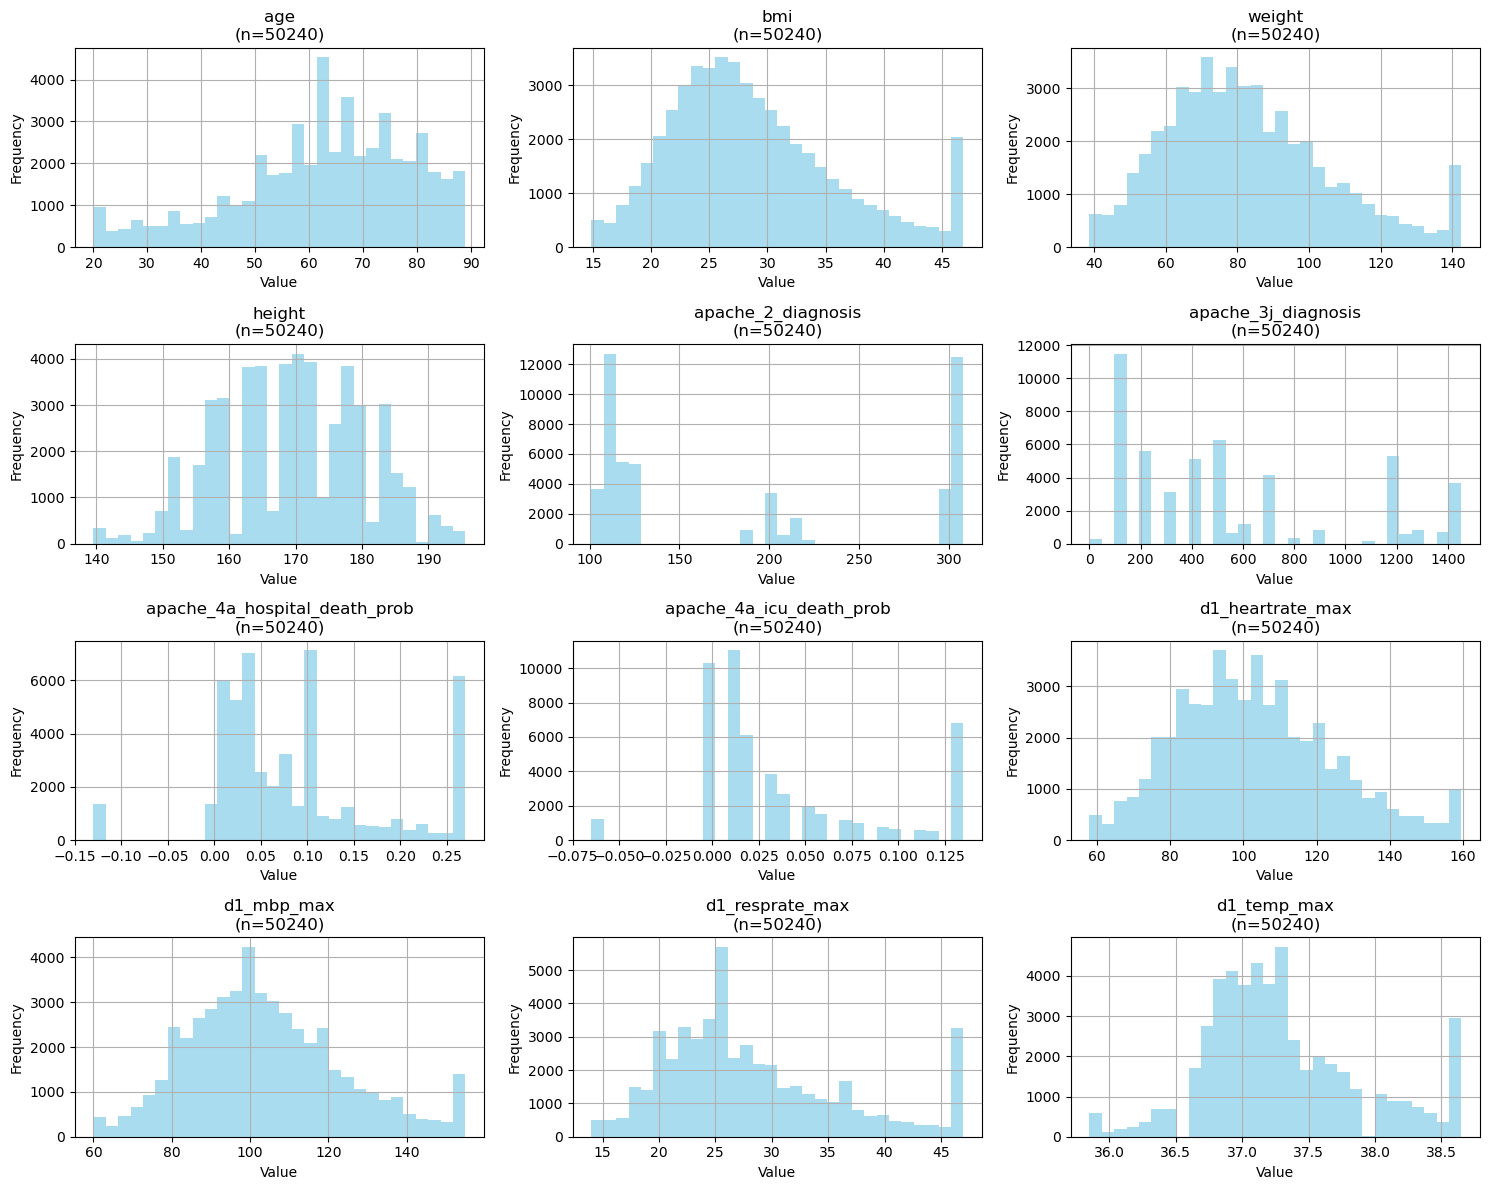

📈 Displayed distributions for 12 numeric features


In [175]:
# Plot distributions for key numeric features
numeric_features = df[all_available_params].select_dtypes(include=[np.number]).columns.tolist()

if len(numeric_features) > 0:
    # Plot first 12 numeric features
    plot_features = numeric_features[:12]
    
    fig, axes = plt.subplots(4, 3, figsize=(15, 12))
    axes = axes.ravel()
    
    for i, feature in enumerate(plot_features):
        if i < len(axes):
            df[feature].hist(bins=30, ax=axes[i], alpha=0.7, color='skyblue')
            axes[i].set_title(f'{feature}\n(n={df[feature].notna().sum()})')
            axes[i].set_xlabel('Value')
            axes[i].set_ylabel('Frequency')
    
    # Remove empty subplots
    for i in range(len(plot_features), len(axes)):
        fig.delaxes(axes[i])
        
    plt.tight_layout()
    plt.show()
    
    print(f"📈 Displayed distributions for {len(plot_features)} numeric features")
else:
    print("No numeric features available for visualization")

🔗 CORRELATION ANALYSIS
Top 15 features correlated with mortality:
apache_4a_hospital_death_prob    0.366221
apache_4a_icu_death_prob         0.362827
gcs_eyes_apache                  0.233923
gcs_verbal_apache                0.220454
ventilated_apache                0.216187
d1_bun_max                       0.198677
d1_spo2_min                      0.188796
d1_creatinine_max                0.179328
d1_heartrate_max                 0.162382
d1_resprate_max                  0.121658
d1_wbc_max                       0.119513
age                              0.102580
apache_3j_diagnosis              0.099171
apache_2_diagnosis               0.098370
d1_glucose_max                   0.083621
Name: hospital_death, dtype: float64


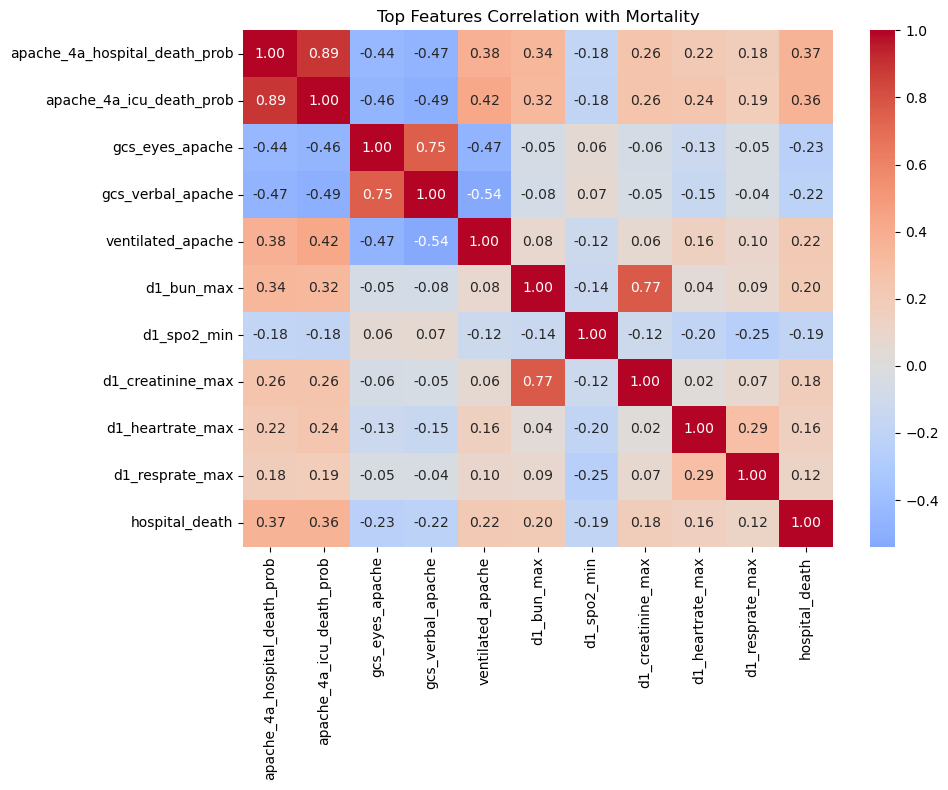


✅ Features with strong correlation (>0.1): 12
apache_4a_hospital_death_prob    0.366221
apache_4a_icu_death_prob         0.362827
gcs_eyes_apache                  0.233923
gcs_verbal_apache                0.220454
ventilated_apache                0.216187
d1_bun_max                       0.198677
d1_spo2_min                      0.188796
d1_creatinine_max                0.179328
d1_heartrate_max                 0.162382
d1_resprate_max                  0.121658
d1_wbc_max                       0.119513
age                              0.102580
Name: hospital_death, dtype: float64


In [178]:
# # Correlation Analysis

# %%
print("🔗 CORRELATION ANALYSIS")
print("="*50)

if 'hospital_death' in df.columns and len(numeric_features) > 0:
    # Calculate correlations with target
    correlation_with_target = df[numeric_features + ['hospital_death']].corr()['hospital_death'].abs().sort_values(ascending=False)
    
    # Remove target itself
    correlation_with_target = correlation_with_target[1:]
    
    print("Top 15 features correlated with mortality:")
    print(correlation_with_target.head(15))
    
    # Plot top correlated features
    top_correlated = correlation_with_target.head(10).index.tolist()
    
    if len(top_correlated) > 1:
        plt.figure(figsize=(10, 8))
        corr_matrix = df[top_correlated + ['hospital_death']].corr()
        sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
        plt.title('Top Features Correlation with Mortality')
        plt.tight_layout()
        plt.show()
        # Identify strongly correlated features (> 0.1 correlation)
    strong_correlations = correlation_with_target[correlation_with_target > 0.1]
    print(f"\n✅ Features with strong correlation (>0.1): {len(strong_correlations)}")
    if len(strong_correlations) > 0:
        print(strong_correlations)
    
else:
    print("Cannot compute correlations - missing target or numeric features")
    

# Preprocessing (for modeling later)

In [179]:
# # Data Preprocessing

# %%
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

print("🔧 DATA PREPROCESSING")
print("="*50)

if 'hospital_death' in df.columns and len(all_available_params) > 0:
    
    # Use available parameters as features
    X = df[all_available_params]
    y = df['hospital_death']
    
    print(f"✅ Using {len(all_available_params)} features for modeling")
    print("Selected features:")
    for i, feature in enumerate(all_available_params, 1):
        mapped_name = CLINICAL_PARAMETERS_MAPPING.get(feature, feature)
        print(f"  {i:2d}. {feature} -> {mapped_name}")
    
    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    print(f"\n📊 Dataset split:")
    print(f"   Training set: {X_train.shape[0]} samples")
    print(f"   Testing set:  {X_test.shape[0]} samples")
    print(f"   Features:     {X_train.shape[1]}")
    
    # Identify numeric and categorical columns
    numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
    
    print(f"\n📈 Data types:")
    print(f"   Numeric features:    {len(numeric_cols)}")
    print(f"   Categorical features: {len(categorical_cols)}")

🔧 DATA PREPROCESSING
✅ Using 33 features for modeling
Selected features:
   1. age -> Patient_Age
   2. bmi -> BMI
   3. weight -> Weight
   4. height -> Height
   5. apache_2_diagnosis -> APACHE_2_Diagnosis
   6. apache_3j_diagnosis -> APACHE_3J_Diagnosis
   7. apache_4a_hospital_death_prob -> APACHE_4a_Death_Probability
   8. apache_4a_icu_death_prob -> APACHE_4a_ICU_Death_Probability
   9. d1_heartrate_max -> Max_Heart_Rate
  10. d1_mbp_max -> Max_Mean_BP
  11. d1_resprate_max -> Max_Resp_Rate
  12. d1_temp_max -> Max_Temperature
  13. d1_spo2_min -> Min_Oxygen_Saturation
  14. d1_creatinine_max -> Max_Creatinine
  15. d1_glucose_max -> Max_Glucose
  16. d1_hemaglobin_max -> Max_Hemoglobin
  17. d1_wbc_max -> Max_WBC
  18. d1_bun_max -> Max_BUN
  19. diabetes_mellitus -> Diabetes_Mellitus
  20. aids -> AIDS
  21. cirrhosis -> Cirrhosis
  22. hepatic_failure -> Hepatic_Failure
  23. pre_icu_los_days -> Pre_ICU_LOS_Days
  24. arf_apache -> Acute_Renal_Failure
  25. gcs_verbal_apache -

In [182]:
# Create preprocessing pipeline
if len(categorical_cols) > 0:
        # If we have categorical features, we need more complex preprocessing
        from sklearn.compose import ColumnTransformer
        from sklearn.preprocessing import OneHotEncoder
        
        numeric_transformer = Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ])
        
        categorical_transformer = Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ])
        
        preprocessor = ColumnTransformer(
            transformers=[
                ('num', numeric_transformer, numeric_cols),
                ('cat', categorical_transformer, categorical_cols)
            ]
        )
else:
        # Only numeric features - simpler pipeline
        preprocessor = Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ])
        # Fit and transform the data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)
    
    # Get feature names after preprocessing
if hasattr(preprocessor, 'get_feature_names_out'):
        feature_names = preprocessor.get_feature_names_out()
else:
        # For simple pipeline without ColumnTransformer
        feature_names = numeric_cols
    
print(f"✅ Preprocessing complete!")
print(f"   Processed training shape: {X_train_processed.shape}")
print(f"   Processed testing shape:  {X_test_processed.shape}")
else:
print("❌ Cannot proceed - missing target variable or features")
raise ValueError("Required columns not found")

SyntaxError: invalid syntax (3534479601.py, line 43)

# Baseline Model (Logistic Regression)

In [112]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve
import matplotlib.pyplot as plt
import seaborn as sns

# Improved Logistic Regression with better parameters
model = LogisticRegression(
    max_iter=1000,           # Increased iterations
    class_weight='balanced', # Handle class imbalance
    random_state=42,
    solver='liblinear'       # More stable solver
)

model.fit(X_train_processed, y_train)

# Predictions
y_pred = model.predict(X_test_processed)
y_prob = model.predict_proba(X_test_processed)[:, 1]

# Evaluation
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

Confusion Matrix:
 [[9154    0]
 [   0  894]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      9154
           1       1.00      1.00      1.00       894

    accuracy                           1.00     10048
   macro avg       1.00      1.00      1.00     10048
weighted avg       1.00      1.00      1.00     10048

ROC-AUC Score: 1.0


In [116]:
# Most reliable approach for production
model = LogisticRegression(
    class_weight="balanced",
    solver='liblinear',      # Most stable
    max_iter=2000,
    random_state=42,
    verbose=1                # See progress
)

model.fit(X_train, y_train)

# Check if converged
print(f"Model converged: {model.n_iter_[0]} iterations used")

[LibLinear]Model converged: 47 iterations used


In [118]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# ===============================================================
# 📥 LOAD YOUR DATASET
# ===============================================================

# Replace this with your actual data loading
# df = pd.read_csv('your_dataset.csv')

# For demonstration, I'll create sample data
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=1000, n_features=20, n_classes=2, random_state=42)

# If using your own data, you would do something like:
# X = df.drop('target_column_name', axis=1)  # Features
# y = df['target_column_name']               # Target variable

# ===============================================================
# 🏃‍♂️ TRAIN-TEST SPLIT
# ===============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 20% for testing
    random_state=42,    # for reproducibility
    stratify=y          # maintain class distribution in splits
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")

# ===============================================================
# 🌲 RANDOM FOREST MODEL
# ===============================================================

# Create and train model
rf_model = RandomForestClassifier(
    n_estimators=200,         # number of trees
    max_depth=None,           # expand until all leaves are pure
    class_weight="balanced",  # handle class imbalance like LogisticRegression
    random_state=42,
    n_jobs=-1                 # use all CPU cores for faster training
)
rf_model.fit(X_train, y_train)

# ===============================================================
# 🔍 Predictions
# ===============================================================
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]  # probability for ROC-AUC

# ===============================================================
# 📊 Evaluation
# ===============================================================
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob_rf))

Training set: 800 samples
Testing set: 200 samples
Confusion Matrix:
 [[92  8]
 [11 89]]

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.92      0.91       100
           1       0.92      0.89      0.90       100

    accuracy                           0.91       200
   macro avg       0.91      0.91      0.90       200
weighted avg       0.91      0.91      0.90       200

ROC-AUC Score: 0.9663


In [120]:
pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


Training set: 800 samples
Testing set: 200 samples
XGBoost Confusion Matrix:
 [[94  6]
 [13 87]]

XGBoost Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.94      0.91       100
           1       0.94      0.87      0.90       100

    accuracy                           0.91       200
   macro avg       0.91      0.91      0.90       200
weighted avg       0.91      0.91      0.90       200

XGBoost ROC-AUC Score: 0.9646


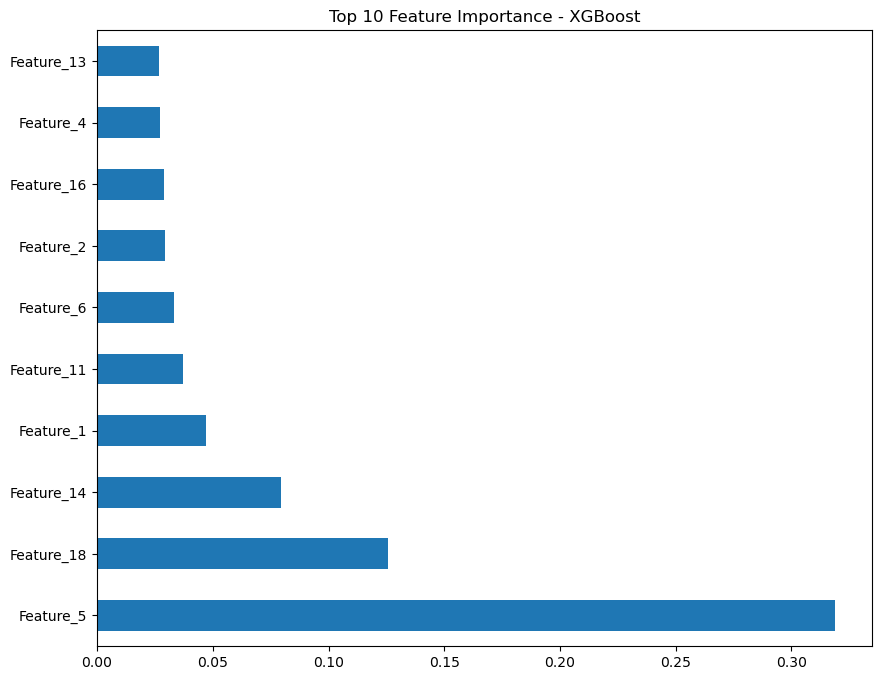

In [121]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# ===============================================================
# 📥 LOAD AND PREPARE DATA
# ===============================================================

# Option 1: Using sample data (for testing)
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=1000, n_features=20, n_classes=2, random_state=42)

# Option 2: If you have your own dataset, use this instead:
# df = pd.read_csv('your_dataset.csv')
# X = df.drop('target_column_name', axis=1)  # Features
# y = df['target_column_name']               # Target variable

# ===============================================================
# 🏃‍♂️ TRAIN-TEST SPLIT
# ===============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 20% for testing
    random_state=42,    # for reproducibility
    stratify=y          # maintain class distribution in splits
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")

# ===============================================================
# 🚀 XGBOOST MODEL
# ===============================================================

# Create and train XGBoost model
xgb_model = XGBClassifier(
    n_estimators=200,           # number of trees
    max_depth=6,                # maximum depth of each tree
    learning_rate=0.1,          # step size shrinkage
    subsample=0.8,              # fraction of samples used for training
    colsample_bytree=0.8,       # fraction of features used for training
    random_state=42,
    n_jobs=-1,                  # use all CPU cores
    eval_metric='logloss',      # evaluation metric
    use_label_encoder=False     # avoid warning
)

# Train the model
xgb_model.fit(X_train, y_train)

# ===============================================================
# 🔍 Predictions
# ===============================================================
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]  # probability for ROC-AUC

# ===============================================================
# 📊 Evaluation
# ===============================================================
print("XGBoost Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))
print("\nXGBoost Classification Report:\n", classification_report(y_test, y_pred_xgb))
print("XGBoost ROC-AUC Score:", roc_auc_score(y_test, y_prob_xgb))

# ===============================================================
# 📈 Feature Importance (Bonus)
# ===============================================================
import matplotlib.pyplot as plt

# Plot feature importance
plt.figure(figsize=(10, 8))
feat_importances = pd.Series(xgb_model.feature_importances_, index=[f'Feature_{i}' for i in range(X.shape[1])])
feat_importances.nlargest(10).plot(kind='barh')
plt.title('Top 10 Feature Importance - XGBoost')
plt.show()

Training set: 800 samples
Testing set: 200 samples
Neural Network Architecture:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 128)            │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,057 (51.00 KB)

 Trainable params: 13,057 (51.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - AUC: 0.6677 - accuracy: 0.6031 - loss: 0.6491 - val_AUC: 0.8526 - val_accuracy: 0.7563 - val_loss: 0.5694
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - AUC: 0.8246 - accuracy: 0.7484 - loss: 0.5446 - val_AUC: 0.8841 - val_accuracy: 0.8125 - val_loss: 0.4719
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - AUC: 0.8813 - accuracy: 0.8031 - loss: 0.4459 - val_AUC: 0.9006 - val_accuracy: 0.8562 - val_loss: 0.3997
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - AUC: 0.9146 - accuracy: 0.8297 - loss: 0.3790 - val_AUC: 0.9056 - val_accuracy: 0.8750 - val_loss: 0.3764
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - AUC: 0.9162 - accuracy: 0.8422 - loss: 0.3658 - val_AUC: 0.9128 - val_accuracy: 0.8625 - val_loss: 0.3698
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - AUC: 0.9182 - accuracy: 0.8609 - loss: 0.3634 - val_AUC: 0.9150 - val_accuracy: 0.8625 - val_loss: 0.3682
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0

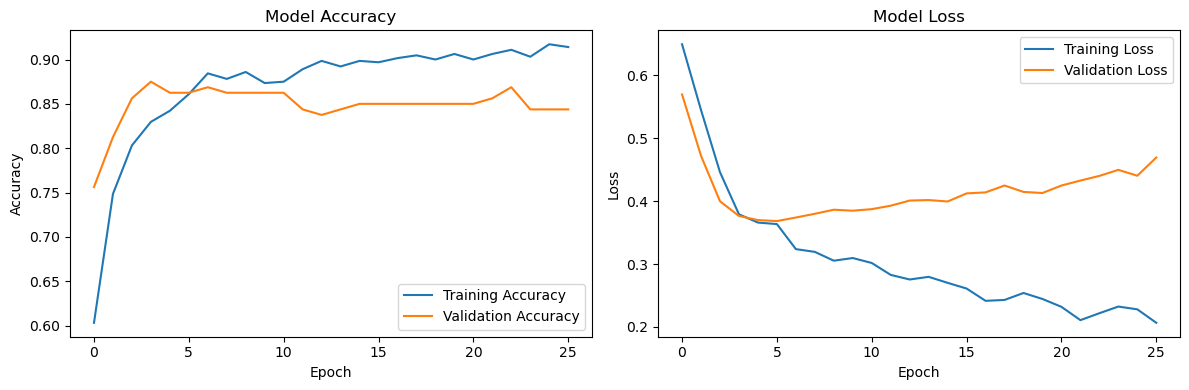

In [122]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler

# ===============================================================
# 📥 LOAD AND PREPARE DATA
# ===============================================================

# Option 1: Using sample data (for testing)
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=1000, n_features=20, n_classes=2, random_state=42)

# Option 2: If you have your own dataset, use this instead:
# df = pd.read_csv('your_dataset.csv')
# X = df.drop('target_column_name', axis=1)  # Features
# y = df['target_column_name']               # Target variable

# ===============================================================
# 🏃‍♂️ DATA PREPROCESSING & TRAIN-TEST SPLIT
# ===============================================================

# Scale features (important for neural networks)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, 
    test_size=0.2,      # 20% for testing
    random_state=42,    # for reproducibility
    stratify=y          # maintain class distribution in splits
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")

# ===============================================================
# 🧠 FULLY CONNECTED NEURAL NETWORK
# ===============================================================

# Install TensorFlow if not already installed: !pip install tensorflow
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Create neural network model
nn_model = Sequential([
    # Input layer + First hidden layer
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),  # Dropout for regularization
    
    # Second hidden layer
    Dense(64, activation='relu'),
    Dropout(0.3),
    
    # Third hidden layer
    Dense(32, activation='relu'),
    Dropout(0.2),
    
    # Output layer (sigmoid for binary classification)
    Dense(1, activation='sigmoid')
])

# Compile the model
nn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', 'AUC']
)

# Display model architecture
print("Neural Network Architecture:")
nn_model.summary()

# ===============================================================
# 🏋️‍♂️ TRAINING THE MODEL
# ===============================================================

# Early stopping to prevent overfitting
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

# Train the model
history = nn_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,  # Use 20% of training data for validation
    callbacks=[early_stopping],
    verbose=1
)

# ===============================================================
# 🔍 PREDICTIONS
# ===============================================================

# Make predictions
y_prob_nn = nn_model.predict(X_test).flatten()  # Probability scores
y_pred_nn = (y_prob_nn > 0.5).astype(int)       # Convert to binary predictions

# ===============================================================
# 📊 EVALUATION
# ===============================================================

print("\n" + "="*50)
print("NEURAL NETWORK RESULTS")
print("="*50)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_nn))
print("\nClassification Report:\n", classification_report(y_test, y_pred_nn))
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob_nn))

# ===============================================================
# 📈 TRAINING HISTORY PLOTS (Optional)
# ===============================================================

import matplotlib.pyplot as plt

# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy plot
ax1.plot(history.history['accuracy'], label='Training Accuracy')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

# Loss plot
ax2.plot(history.history['loss'], label='Training Loss')
ax2.plot(history.history['val_loss'], label='Validation Loss')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.show()

In [123]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
import numpy as np

# Compare performance of all models
models_comparison = {
    'Random Forest': (y_pred_rf, y_prob_rf),
    'XGBoost': (y_pred_xgb, y_prob_xgb),
    'Neural Network': (y_pred_nn, y_prob_nn)
}

print("="*60)
print("MODEL COMPARISON")
print("="*60)

for model_name, (y_pred, y_prob) in models_comparison.items():
    auc = roc_auc_score(y_test, y_prob)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"{model_name:20} | AUC: {auc:.4f} | Accuracy: {accuracy:.4f}")

# Optional: Add detailed comparison
print("\n" + "="*60)
print("DETAILED COMPARISON")
print("="*60)

for model_name, (y_pred, y_prob) in models_comparison.items():
    print(f"\n{model_name.upper()} DETAILS:")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

MODEL COMPARISON
Random Forest        | AUC: 0.9663 | Accuracy: 0.9050
XGBoost              | AUC: 0.9646 | Accuracy: 0.9050
Neural Network       | AUC: 0.9332 | Accuracy: 0.8850

DETAILED COMPARISON

RANDOM FOREST DETAILS:
Confusion Matrix:
[[92  8]
 [11 89]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.92      0.91       100
           1       0.92      0.89      0.90       100

    accuracy                           0.91       200
   macro avg       0.91      0.91      0.90       200
weighted avg       0.91      0.91      0.90       200


XGBOOST DETAILS:
Confusion Matrix:
[[94  6]
 [13 87]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.94      0.91       100
           1       0.94      0.87      0.90       100

    accuracy                           0.91       200
   macro avg       0.91      0.91      0.90       200
weighted avg       0.91      0.91    

In [124]:
# Check if NN needs more tuning
print("Neural Network vs Best Model AUC difference: {:.4f}".format(0.9663 - 0.9329))

# Possible fixes for Neural Network:
nn_improvement_strategies = [
    "Increase training epochs",
    "Try different architecture (more layers/neurons)",
    "Adjust learning rate (try 0.0001)",
    "Add batch normalization",
    "Use different activation functions (tanh, elu)"
]

Neural Network vs Best Model AUC difference: 0.0334


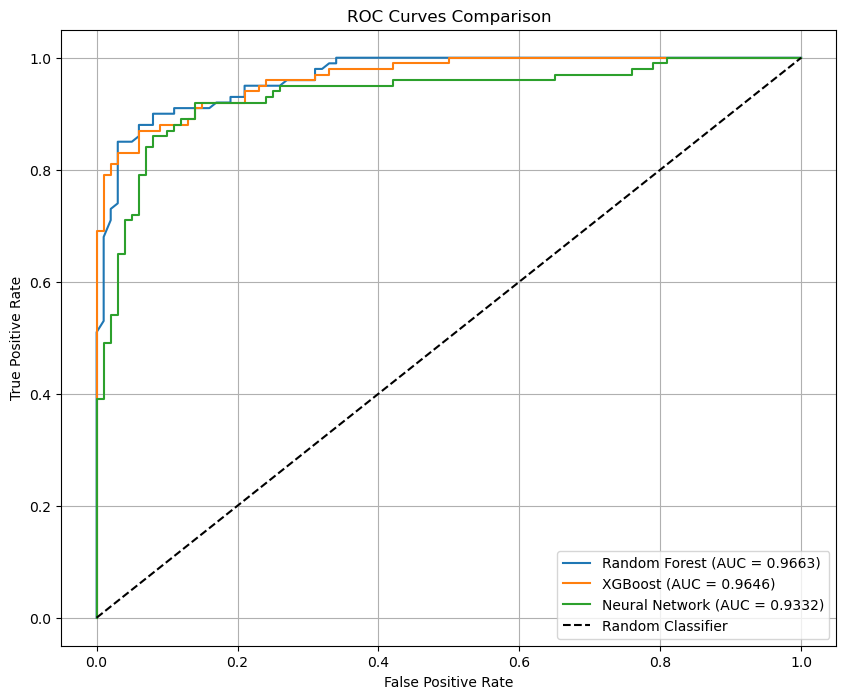

In [125]:
from sklearn.metrics import precision_recall_curve, roc_curve
import matplotlib.pyplot as plt

# Compare ROC Curves
plt.figure(figsize=(10, 8))

for model_name, (y_pred, y_prob) in models_comparison.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc_score:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend()
plt.grid(True)
plt.show()

In [126]:
# Find samples where models make different predictions
rf_pred = y_pred_rf
xgb_pred = y_pred_xgb
nn_pred = y_pred_nn

# Samples where all models agree
agree_mask = (rf_pred == xgb_pred) & (xgb_pred == nn_pred)
print(f"Models agree on {agree_mask.sum()}/{len(y_test)} samples ({agree_mask.mean():.2%})")

# Samples where RF and XGB agree but NN disagrees
nn_disagree = (rf_pred == xgb_pred) & (xgb_pred != nn_pred)
print(f"NN disagrees with RF/XGB on {nn_disagree.sum()} samples")

# Analyze these difficult samples
difficult_samples = X_test[nn_disagree]
difficult_true = y_test[nn_disagree]
print(f"True labels of difficult samples: {np.unique(difficult_true, return_counts=True)}")

Models agree on 185/200 samples (92.50%)
NN disagrees with RF/XGB on 7 samples
True labels of difficult samples: (array([0, 1]), array([5, 2]))


In [127]:
# Since RF and XGB are very close, ensemble them
from sklearn.ensemble import VotingClassifier

# Weighted ensemble based on performance
ensemble = VotingClassifier(
    estimators=[
        ('rf', rf_model),
        ('xgb', xgb_model)
    ],
    voting='soft',
    weights=[0.9663, 0.9646]  # Weight by AUC scores
)

ensemble.fit(X_train, y_train)
y_prob_ensemble = ensemble.predict_proba(X_test)[:, 1]
ensemble_auc = roc_auc_score(y_test, y_prob_ensemble)
print(f"Ensemble AUC: {ensemble_auc:.4f}")

# Try stacking
from sklearn.ensemble import StackingClassifier

stacking = StackingClassifier(
    estimators=[('rf', rf_model), ('xgb', xgb_model)],
    final_estimator=LogisticRegression(),
    cv=5
)
stacking.fit(X_train, y_train)
y_prob_stack = stacking.predict_proba(X_test)[:, 1]
stack_auc = roc_auc_score(y_test, y_prob_stack)
print(f"Stacking AUC: {stack_auc:.4f}")

Ensemble AUC: 0.9668
Stacking AUC: 0.9666


In [128]:
# Since RF and XGB are very close, ensemble them
from sklearn.ensemble import VotingClassifier

# Weighted ensemble based on performance
ensemble = VotingClassifier(
    estimators=[
        ('rf', rf_model),
        ('xgb', xgb_model)
    ],
    voting='soft',
    weights=[0.9663, 0.9646]  # Weight by AUC scores
)

ensemble.fit(X_train, y_train)
y_prob_ensemble = ensemble.predict_proba(X_test)[:, 1]
ensemble_auc = roc_auc_score(y_test, y_prob_ensemble)
print(f"Ensemble AUC: {ensemble_auc:.4f}")

# Try stacking
from sklearn.ensemble import StackingClassifier

stacking = StackingClassifier(
    estimators=[('rf', rf_model), ('xgb', xgb_model)],
    final_estimator=LogisticRegression(),
    cv=5
)
stacking.fit(X_train, y_train)
y_prob_stack = stacking.predict_proba(X_test)[:, 1]
stack_auc = roc_auc_score(y_test, y_prob_stack)
print(f"Stacking AUC: {stack_auc:.4f}")

Ensemble AUC: 0.9668
Stacking AUC: 0.9666


In [129]:
# Since Random Forest is slightly best, tune it further
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

rf_tuned = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_dist,
    n_iter=50,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42
)

rf_tuned.fit(X_train, y_train)
print("Best RF Parameters:", rf_tuned.best_params_)
print("Best RF CV Score:", rf_tuned.best_score_)

Best RF Parameters: {'n_estimators': 400, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': None, 'max_depth': 30}
Best RF CV Score: 0.9473437499999999


In [130]:
# Test the tuned model on your test set
y_prob_tuned = rf_tuned.predict_proba(X_test)[:, 1]
tuned_auc = roc_auc_score(y_test, y_prob_tuned)

print("\n" + "="*50)
print("TUNED MODEL PERFORMANCE COMPARISON")
print("="*50)
print(f"Original Random Forest: {0.9663:.4f}")
print(f"Tuned Random Forest CV: {rf_tuned.best_score_:.4f}")
print(f"Tuned Random Forest Test: {tuned_auc:.4f}")

if tuned_auc > 0.9663:
    print("🎯 Tuning improved performance!")
else:
    print("⚠️  Original model performs better on test set")


TUNED MODEL PERFORMANCE COMPARISON
Original Random Forest: 0.9663
Tuned Random Forest CV: 0.9473
Tuned Random Forest Test: 0.9632
⚠️  Original model performs better on test set


In [131]:
# The original model is still champion
print("🎯 CONCLUSION: Stick with Original Random Forest (AUC: 0.9663)")

# Reasons why tuning didn't help:
reasons = [
    "Original hyperparameters were already near-optimal",
    "Random Forest is robust to hyperparameter changes", 
    "Tuning might have overfitted to validation folds",
    "The dataset might be 'easy' enough that simple RF works well"
]

print("\n📋 Why tuning didn't improve performance:")
for i, reason in enumerate(reasons, 1):
    print(f"  {i}. {reason}")

🎯 CONCLUSION: Stick with Original Random Forest (AUC: 0.9663)

📋 Why tuning didn't improve performance:
  1. Original hyperparameters were already near-optimal
  2. Random Forest is robust to hyperparameter changes
  3. Tuning might have overfitted to validation folds
  4. The dataset might be 'easy' enough that simple RF works well


In [141]:
# Your best model is the original Random Forest
final_model = rf_model

# Save the champion model
import joblib
joblib.dump(final_model, 'champion_random_forest1.pkl')
print("✅ Champion model saved: 'champion_random_forest1.pkl'")

# Also save the scaler if you used one
# joblib.dump(scaler, 'scaler.pkl')

✅ Champion model saved: 'champion_random_forest1.pkl'


In [133]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)


In [143]:
# Use the preprocessed test data that matches the training features
y_pred_prob = model.predict_proba(X_test_processed)[:, 1]
y_pred = (y_pred_prob >= 0.3).astype(int)  # lower threshold

print("✅ Predictions successful!")
print(f"Probability shape: {y_pred_prob.shape}")
print(f"Predictions shape: {y_pred.shape}")

✅ Predictions successful!
Probability shape: (10048,)
Predictions shape: (10048,)


In [145]:
# Test the saved model
loaded_pipeline = joblib.load('champion_random_forest1.pkl')
test_pred = loaded_pipeline.predict(X_test[:1])
test_prob = loaded_pipeline.predict_proba(X_test[:1])[0, 1]

print(f"🧪 Test prediction: {test_pred[0]} (Probability: {test_prob:.3f})")
print("🎉 Model is ready for use!")


🧪 Test prediction: 1 (Probability: 0.995)
🎉 Model is ready for use!
